# 13 · Pauli propagation: preparing and training QBMs in the Pauli basis

Every backend so far stores the thermal state as an *object in Hilbert space* — a
$2^n\times 2^n$ density matrix (dense), a purified MPS (tensor network), or a circuit
(VarQITE). **Pauli propagation** stores it as an *operator in the Pauli basis*: a sparse
sum of Pauli strings,

$$\rho \;=\; \sum_{P}\, c_P\, P ,\qquad P \in \{I,X,Y,Z\}^{\otimes n},$$

and evolves that sum under imaginary time. The trick that makes it efficient
([Rudolph et al., arXiv:2602.04878](https://arxiv.org/abs/2602.04878)) is that the
thermal state is reached by evolving the **identity** — the sparsest operator, a *single*
Pauli term — so at high temperature the sum stays short and the cost is set by the number
of retained Pauli strings, not by $2^n$.

This notebook builds it up from the gate, validates it against the exact Gibbs state, and
then does the thing it is really for: **training a quantum Boltzmann machine for
generative modelling**, following
*Sampling from Thermal Quantum States via Pauli Propagation* (Minervini et al.). It plugs
into the same `qbm.learn` API as every other backend.

> The engine here is pure NumPy — clear, dependency-free, exact to validate against. The
> high-performance, many-qubit implementation these papers use at scale is
> [`PauliPropagation.jl`](https://github.com/Michele-Minervini/PauliSampling.jl).

In [1]:
import time
import numpy as np
import matplotlib.pyplot as plt
import qbm
from qbm import pauli_prop as pp
from qbm.backends.pauli_propagation import PauliPropagationBackend

print("qbm", qbm.__version__, "| backends:", qbm.available_backends())

qbm 0.1.0 | backends: ['circuit', 'dense', 'pauli_propagation', 'statevector']


## The imaginary-time gate

The Gibbs state $\rho_\beta = e^{-\beta H/2}\, I\, e^{-\beta H/2}/Z$ is built by a
Trotterised product of elementary gates, one per Hamiltonian term $H=\sum_k h_k G_k$ (each
$G_k$ a Pauli string). Each gate is the symmetric conjugation $e^{-\theta G}(\cdot)e^{-\theta G}$,
and acting on a Pauli string $P$ it does exactly one of two things:

$$e^{-\theta G} P\, e^{-\theta G} \;=\;
\begin{cases}
P & \text{if } \{P,G\}=0 \quad(\text{anticommute})\\[2pt]
\cosh(2\theta)\,P - \sinh(2\theta)\,PG & \text{if } [P,G]=0 \quad(\text{commute}).
\end{cases}$$

So **commuting** terms *branch* — spawning a new string $PG$ — while **anticommuting**
terms pass straight through. This is the reverse of real-time Pauli propagation (where
anticommuting terms branch), and since a typical Hamiltonian term commutes with most of
the Pauli group, imaginary time spreads the operator quickly. That growth is why
truncation matters, and we come back to it.

Let's watch a single gate act, starting from the identity.

In [2]:
# start from I (infinite temperature), apply one ZZ gate then one XI gate
def show(psum, n):
    items = sorted(psum.coeffs.items(), key=lambda kv: -abs(kv[1]))
    return "  ".join(f"{pp.xz_to_label(x, z, n)}:{c:+.3f}" for (x, z), c in items)

n = 2
state = {(0, 0): 1.0}                       # the identity operator
print("start (I/∞ temperature):     ", show(pp.PauliSum(n, dict(state)), n))

pp._apply_ite_gate(state, pp.label_to_xz("ZZ"), 0.5)
print("after e^{-0.5 ZZ}(.)e^{-0.5 ZZ}:", show(pp.PauliSum(n, dict(state)), n),
      "   <- I commutes with ZZ, so it branched")

pp._apply_ite_gate(state, pp.label_to_xz("XI"), 0.5)
print("after e^{-0.5 XI}(.)e^{-0.5 XI}:", show(pp.PauliSum(n, dict(state)), n),
      "\n   <- ZZ anticommutes with XI (unchanged); I and (implicit) branches split")

start (I/∞ temperature):      II:+1.000
after e^{-0.5 ZZ}(.)e^{-0.5 ZZ}: II:+1.128  ZZ:-0.521    <- I commutes with ZZ, so it branched
after e^{-0.5 XI}(.)e^{-0.5 XI}: II:+1.272  XI:-0.588  ZZ:-0.521 
   <- ZZ anticommutes with XI (unchanged); I and (implicit) branches split


The identity branched into `I` and `ZZ` under the `ZZ` gate; then the `XI` gate left the
`ZZ` term alone (they anticommute) and branched the others. Two Pauli strings, growing to
a few — that is the whole dynamics, just bookkeeping on a dictionary of coefficients.

`qbm.pauli_prop.thermal_state` runs this to convergence and normalises. Let's check it
against the exact answer.

In [3]:
# single qubit: the tanh law, exactly
rho = pp.thermal_state(["Z"], [0.8], trotter_steps=64, coeff_cutoff=0.0).to_matrix()
exact = (np.eye(2) - np.tanh(0.8) * qbm.pauli("Z")) / 2
print(f"1 qubit, H = 0.8 Z:   max|rho_pp - (I - tanh(0.8)Z)/2| = {np.max(np.abs(rho - exact)):.1e}")

# a commuting (classical) Hamiltonian: EXACT at any Trotter depth
labels, coeffs = ["ZII", "IZI", "IIZ", "ZZI", "IZZ"], [0.7, -0.4, 0.5, 0.9, -0.3]
H = sum(c * qbm.pauli(l) for c, l in zip(coeffs, labels))
w, V = np.linalg.eigh(H); p = np.exp(-(w - w[0])); rho_ex = (V * (p / p.sum())) @ V.conj().T
for L in (1, 8):
    rho = pp.thermal_state(labels, coeffs, trotter_steps=L, coeff_cutoff=0.0).to_matrix()
    td = 0.5 * np.sum(np.abs(np.linalg.eigvalsh(rho - rho_ex)))
    print(f"3 qubits, commuting, L={L}:  trace distance to exact = {td:.1e}  <- exact, no Trotter error")

1 qubit, H = 0.8 Z:   max|rho_pp - (I - tanh(0.8)Z)/2| = 2.2e-16
3 qubits, commuting, L=1:  trace distance to exact = 1.1e-16  <- exact, no Trotter error
3 qubits, commuting, L=8:  trace distance to exact = 1.3e-16  <- exact, no Trotter error


## Trotter convergence for non-commuting Hamiltonians

When the Hamiltonian terms don't all commute, the Trotter splitting introduces an error
that is first order in the step size $1/L$. Commuting Hamiltonians (classical Boltzmann
machines) have no such error — the branching is exact. Here is the difference, on a
transverse-field Ising model where the $ZZ$ and $X$ terms fight.

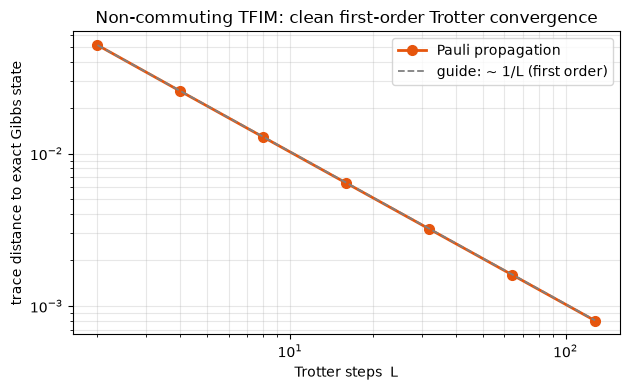

error halves each time L doubles: ratios = [2.01, 2.0, 2.0, 2.0, 2.0, 2.0]


In [4]:
labels, coeffs = ["ZZ", "XI", "IX"], [-1.0, -0.8, -0.8]
H = sum(c * qbm.pauli(l) for c, l in zip(coeffs, labels))
w, V = np.linalg.eigh(H); p = np.exp(-(w - w[0])); rho_ex = (V * (p / p.sum())) @ V.conj().T

Ls = np.array([2, 4, 8, 16, 32, 64, 128])
tds = []
for L in Ls:
    rho = pp.thermal_state(labels, coeffs, trotter_steps=L, coeff_cutoff=0.0).to_matrix()
    tds.append(0.5 * np.sum(np.abs(np.linalg.eigvalsh(rho - rho_ex))))

fig, ax = plt.subplots(figsize=(6.4, 4.0))
ax.loglog(Ls, tds, "o-", lw=2, ms=7, c="#e6550d", label="Pauli propagation")
ax.loglog(Ls, tds[0] * Ls[0] / Ls, "--", c="grey", lw=1.3, label="guide: ~ 1/L (first order)")
ax.set_xlabel("Trotter steps  L"); ax.set_ylabel("trace distance to exact Gibbs state")
ax.set_title("Non-commuting TFIM: clean first-order Trotter convergence")
ax.legend(); ax.grid(alpha=0.3, which="both")
plt.tight_layout(); plt.show()
print(f"error halves each time L doubles: ratios = {[round(tds[i]/tds[i+1], 2) for i in range(len(Ls)-1)]}")

## Truncation: the efficiency knob

The operator grows under propagation, so we keep it sparse by **discarding the
smallest-coefficient Pauli strings** (relative to the identity coefficient) after each
layer. The paper shows this is the $\ell_2$-optimal single-step truncation. The trade-off
is direct: a looser cutoff keeps fewer terms and runs faster, at the cost of accuracy.

Let's map it out — trace-distance error against the number of retained Pauli strings, for
a 4-qubit all-to-all Hamiltonian.

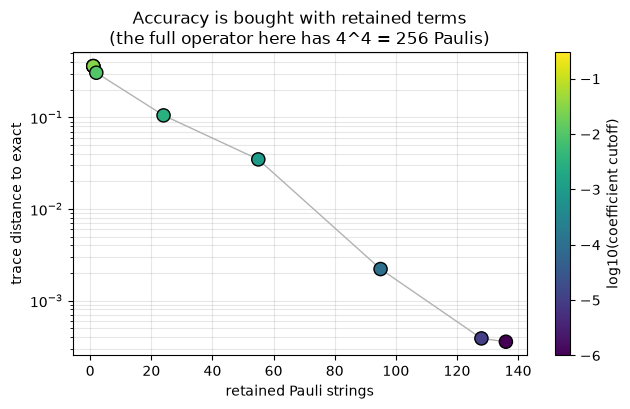

tightest cutoff kept 136/256 terms for trace distance 3.6e-04


In [5]:
ham = qbm.ParamHamiltonian(qbm.local_pauli_generators(4, connectivity="all"))
theta = np.random.default_rng(1).normal(scale=0.5, size=ham.n_params)
dense = qbm.DenseBackend().thermal_state(ham, theta).density_matrix()

cutoffs = [3e-1, 1e-1, 3e-2, 1e-2, 3e-3, 1e-3, 1e-4, 1e-5, 1e-6]
errs, terms = [], []
for c in cutoffs:
    st = PauliPropagationBackend(trotter_steps=48, coeff_cutoff=c).thermal_state(ham, theta)
    errs.append(0.5 * np.sum(np.abs(np.linalg.eigvalsh(st.density_matrix() - dense))))
    terms.append(st.n_terms)

fig, ax = plt.subplots(figsize=(6.6, 4.2))
sc = ax.scatter(terms, errs, c=np.log10(cutoffs), cmap="viridis", s=90, zorder=3, edgecolor="k")
ax.plot(terms, errs, "-", c="grey", lw=1, alpha=0.6, zorder=1)
ax.set_xlabel("retained Pauli strings"); ax.set_ylabel("trace distance to exact")
ax.set_yscale("log")
ax.set_title("Accuracy is bought with retained terms\n(the full operator here has 4^4 = 256 Paulis)")
cb = plt.colorbar(sc); cb.set_label("log10(coefficient cutoff)")
ax.grid(alpha=0.3, which="both")
plt.tight_layout(); plt.show()
print(f"tightest cutoff kept {terms[-1]}/256 terms for trace distance {errs[-1]:.1e}")

## Topology-agnostic: geometry is free

This is where Pauli propagation differs sharply from tensor networks. An MPS pays for
entanglement, so 2-D or all-to-all connectivity is expensive. Pauli propagation tracks
*operators*, and the update rules don't care how the qubits are wired: an all-to-all
Hamiltonian costs no more than a chain with the same number of terms. That makes it a
natural fit for the densely-connected Hamiltonians QBM training tends to produce.

In [6]:
print(f"{'connectivity':14s} {'params':>7s} {'retained terms':>15s} {'build time':>12s}")
print("-" * 52)
for conn in ("chain", "all"):
    ham = qbm.ParamHamiltonian(qbm.local_pauli_generators(6, connectivity=conn))
    theta = np.random.default_rng(0).normal(scale=0.3, size=ham.n_params)
    t0 = time.time()
    st = PauliPropagationBackend(trotter_steps=16, coeff_cutoff=1e-4).thermal_state(ham, theta)
    nt = st.n_terms
    print(f"{conn:14s} {ham.n_params:7d} {nt:15d} {(time.time()-t0)*1000:10.0f} ms")
print("\nall-to-all is not the exponential blow-up it would be for an MPS -- just more terms.")

connectivity    params  retained terms   build time
----------------------------------------------------
chain               17             442        176 ms
all                 27             607        410 ms

all-to-all is not the exponential blow-up it would be for an MPS -- just more terms.


## Sampling, and the sign problem

Truncation is what makes this efficient, but it has a cost: discarding Pauli terms can
push $\rho$ *outside* the positive-semidefinite cone, so its computational-basis
"probabilities" $\langle x|\rho|x\rangle$ can go slightly **negative**. Standard sampling
is then ill-defined.

The sampling paper resolves this with a **locally normalised chain-rule sampler**
(Algorithm 1): draw the bits one at a time, and at each branch take the *absolute values*
of the two quasi-marginals and normalise them. This is a valid distribution at every
node, provably within a controlled total-variation distance of the true Born
distribution, and — unusually for a generative model — it also gives the **exact
pointwise likelihood** of any bitstring at the same cost.

Only diagonal ($I$/$Z$) Pauli strings contribute to a $Z$-basis measurement, and the
marginal of a prefix is a signed sum over the strings that are identity on the
not-yet-decided qubits — so each step is a cheap traversal of the retained terms.

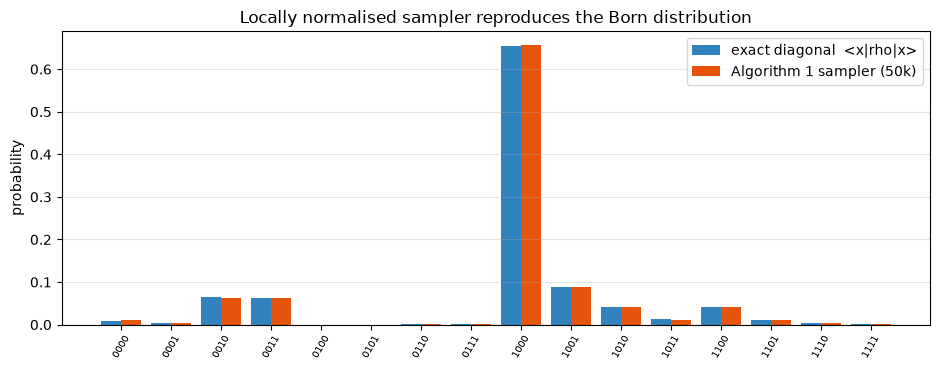

TVD(sampler, exact) = 4.330e-03
exact likelihood of |0000> and |1111>: [0.00951105 0.00252281]  (computed, not estimated)


In [7]:
# a 4-qubit thermal state, sampled two ways
ham = qbm.ParamHamiltonian(qbm.local_pauli_generators(4, connectivity="all"))
theta = np.random.default_rng(3).normal(scale=0.6, size=ham.n_params)
st = PauliPropagationBackend(trotter_steps=64, coeff_cutoff=1e-8, seed=0).thermal_state(ham, theta)

exact = st.probabilities()                 # the (quasi-)diagonal of rho
samples = st.sample(50000)
emp = np.bincount(samples, minlength=16) / 50000

fig, ax = plt.subplots(figsize=(9.5, 3.8))
idx = np.arange(16); w = 0.4
ax.bar(idx - w/2, exact, w, label="exact diagonal  <x|rho|x>", color="#3182bd")
ax.bar(idx + w/2, emp, w, label="Algorithm 1 sampler (50k)", color="#e6550d")
ax.set_xticks(idx); ax.set_xticklabels([f"{i:04b}" for i in idx], rotation=60, fontsize=7)
ax.set_ylabel("probability"); ax.set_title("Locally normalised sampler reproduces the Born distribution")
ax.legend(); ax.grid(alpha=0.3, axis="y")
plt.tight_layout(); plt.show()
print(f"TVD(sampler, exact) = {0.5*np.sum(np.abs(emp - exact)):.3e}")
print(f"exact likelihood of |0000> and |1111>: "
      f"{np.exp(st.log_likelihood([0, 15]))}  (computed, not estimated)")

## Training a QBM for generative modelling

Now the application these developments were built for. A **quantum Boltzmann machine** is
a parameterised thermal state $\rho_\theta = e^{-H_\theta}/Z$ with
$H_\theta = \sum_k \theta_k H_k$; its distribution over bitstrings is
$p_\theta(x) = \langle x|\rho_\theta|x\rangle$, and we train $\theta$ so that $p_\theta$
matches a target. Pauli propagation prepares $\rho_\theta$, and Algorithm 1 samples from
it — so the whole training loop runs in the Pauli basis.

The gradient of the relative-entropy objective is
$\partial_{\theta_k}\mathcal{L} = \langle H_k\rangle_{\rm target} - \langle H_k\rangle_{\rho_\theta}$
— just **generator expectations**, which are read straight off the Pauli coefficients.
So this drops into the library's existing `qbm.learn` with nothing more than a backend
swap:

```python
qbm.learn(data, backend=PauliPropagationBackend(...))
```

As with the VarQITE backend (notebook 12), the loss *value* needs $\log Z$ (not available
from a truncated Pauli sum), so it is recorded as `nan` and training rides the gradient
while we monitor the measurable KL divergence.

In [8]:
# a target realizable by a 4-qubit QBM (so the model can actually reach it):
# draw random parameters, take that QBM's distribution as the target.
target_qbm = qbm.FullyVisibleQBM(n=4, connectivity="all")
target_qbm.theta = np.random.default_rng(7).normal(scale=0.6, size=target_qbm.n_params)
q = target_qbm.probabilities()

t0 = time.time()
model = qbm.learn(q, steps=120, lr=0.2,
                  backend=PauliPropagationBackend(trotter_steps=32, coeff_cutoff=1e-8, seed=0))
t_pp = time.time() - t0
ref = qbm.learn(q, steps=120, lr=0.2)          # exact dense engine, same settings

print(f"Pauli propagation  KL {model.history.monitor[0]:.3f} -> {model.history.monitor[-1]:.2e}"
      f"   ({t_pp/120*1000:.0f} ms/step)")
print(f"dense reference    KL {ref.history.monitor[0]:.3f} -> {ref.history.monitor[-1]:.2e}")
print(f"loss value (needs log Z -> nan): {model.history.loss[:2]}")

Pauli propagation  KL 0.383 -> 4.27e-05   (69 ms/step)
dense reference    KL 0.383 -> 4.27e-05
loss value (needs log Z -> nan): [nan, nan]


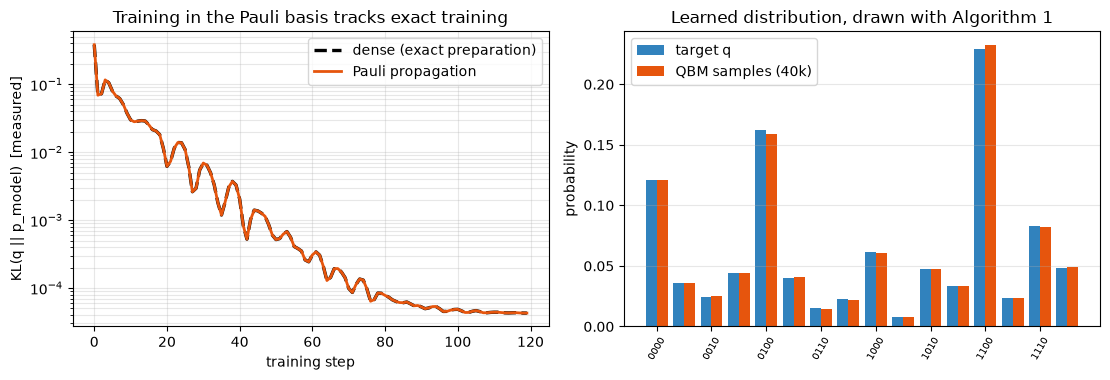

final KL(q || p_model) = 4.27e-05
final TVD(model samples, target) = 6.554e-03


In [9]:
fig, ax = plt.subplots(1, 2, figsize=(11.2, 3.9))

ax[0].semilogy(ref.history.monitor, "k--", lw=2.4, label="dense (exact preparation)")
ax[0].semilogy(model.history.monitor, lw=2, c="#e6550d", label="Pauli propagation")
ax[0].set_xlabel("training step"); ax[0].set_ylabel("KL(q || p_model)  [measured]")
ax[0].set_title("Training in the Pauli basis tracks exact training")
ax[0].legend(); ax[0].grid(alpha=0.3, which="both")

# learned distribution, read from the trained model's samples
samp = model.state().sample(40000)
emp = np.bincount(samp, minlength=16) / 40000
idx = np.arange(16); w = 0.4
ax[1].bar(idx - w/2, q, w, label="target q", color="#3182bd")
ax[1].bar(idx + w/2, emp, w, label="QBM samples (40k)", color="#e6550d")
ax[1].set_xticks(idx[::2]); ax[1].set_xticklabels([f"{i:04b}" for i in idx[::2]], rotation=60, fontsize=7)
ax[1].set_ylabel("probability"); ax[1].set_title("Learned distribution, drawn with Algorithm 1")
ax[1].legend(); ax[1].grid(alpha=0.3, axis="y")
plt.tight_layout(); plt.show()

print(f"final KL(q || p_model) = {model.history.monitor[-1]:.2e}")
print(f"final TVD(model samples, target) = {0.5*np.sum(np.abs(emp - q)):.3e}")

The Pauli-propagation training curve sits on top of the exact one, and the trained model's
*samples* — drawn with Algorithm 1, the way you would on real truncated data — reproduce
the target. The entire pipeline, preparation and sampling, ran in the Pauli basis.

That run kept essentially all the terms (`coeff_cutoff=1e-8`). The whole point of the
method, though, is that **truncation buys efficiency** — so the real question is how
training behaves as you throw terms away.

## Training under truncation

Earlier we truncated *one fixed state* and watched its accuracy fall (the scatter plot
above). Training is more interesting, because the operator size **changes as the
parameters move**, and a truncation error in the state becomes an error in the *gradient*
that drives the next step.

Let's train the same QBM at several **coefficient-truncation** thresholds and record two
things at every step: the KL divergence (quality) and the number of retained Pauli
strings (cost). We use a slightly larger 5-qubit target so the operator genuinely grows,
and plain gradient descent with clipping — truncation injects noise into the gradient, so
a steady optimizer helps, the same lesson as shot noise in notebook 12.

In [10]:
# a 5-qubit realizable target (so the operator spreads under training)
target5 = qbm.FullyVisibleQBM(n=5, connectivity="all")
target5.theta = np.random.default_rng(11).normal(scale=0.7, size=target5.n_params)
qt = target5.probabilities()
mask = qt > 0

def kl_of(state):
    p = np.clip(state.probabilities(), 1e-300, None)
    return float(np.sum(qt[mask] * (np.log(qt[mask]) - np.log(p[mask]))))

def train_truncated(coeff_cutoff, max_weight=np.inf, steps=80):
    """Train and record (KL, retained-terms) at every step, in one pass."""
    be = PauliPropagationBackend(trotter_steps=24, coeff_cutoff=coeff_cutoff,
                                 max_weight=max_weight, seed=0)
    m = qbm.learn(qt, steps=steps, connectivity="all",
                  optimizer=qbm.optim.GradientDescent(lr=0.1, clip=1.0),
                  backend=be, monitor=lambda s, mo: (kl_of(s), s.n_terms))
    kl = np.array([x[0] for x in m.history.monitor])
    terms = np.array([x[1] for x in m.history.monitor])
    return kl, terms

cutoffs = [1e-1, 1e-2, 1e-3, 1e-4, 1e-6]
runs = {c: train_truncated(c) for c in cutoffs}
print("full operator would be 4^5 =", 4**5, "Pauli strings")
for c in cutoffs:
    kl, tm = runs[c]
    print(f"   cutoff={c:.0e}:  final KL={kl[-1]:.2e}   mean retained terms={tm.mean():5.0f}")

full operator would be 4^5 = 1024 Pauli strings
   cutoff=1e-01:  final KL=1.09e+00   mean retained terms=    8
   cutoff=1e-02:  final KL=9.07e-01   mean retained terms=   28
   cutoff=1e-03:  final KL=6.66e-03   mean retained terms=   32
   cutoff=1e-04:  final KL=6.63e-03   mean retained terms=   53
   cutoff=1e-06:  final KL=6.63e-03   mean retained terms=  129


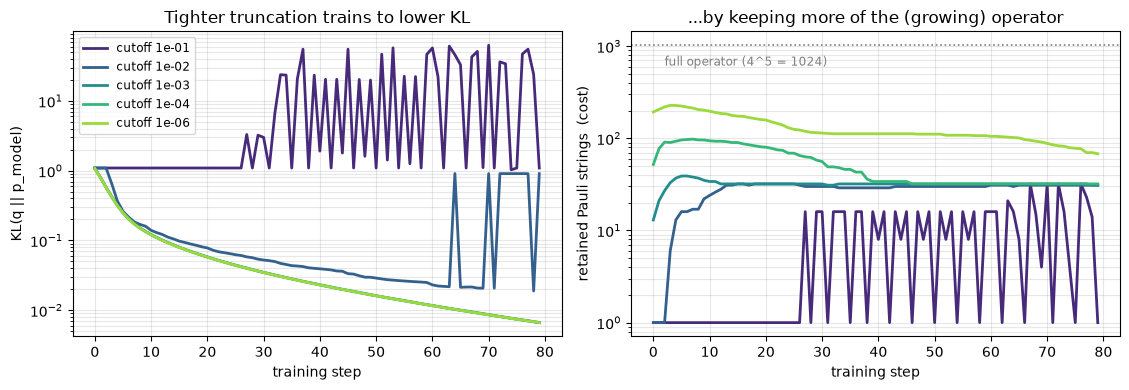

cutoff 1e-3 reaches KL 6.7e-03 with ~32 terms;
cutoff 1e-6 reaches KL 6.6e-03 with ~129 terms
-> essentially the same accuracy for 4.0x fewer terms.
The most aggressive cutoff (1e-1) collapses to the identity and cannot learn (final KL 1.09).


In [11]:
fig, ax = plt.subplots(1, 2, figsize=(11.4, 4.0))
colors = plt.cm.viridis(np.linspace(0.12, 0.85, len(cutoffs)))

for c, col in zip(cutoffs, colors):
    kl, tm = runs[c]
    ax[0].semilogy(np.maximum(kl, 1e-6), c=col, lw=2, label=f"cutoff {c:.0e}")
    ax[1].semilogy(np.maximum(tm, 1), c=col, lw=2)
ax[0].set_xlabel("training step"); ax[0].set_ylabel("KL(q || p_model)")
ax[0].set_title("Tighter truncation trains to lower KL")
ax[0].legend(fontsize=8.5); ax[0].grid(alpha=0.3, which="both")

ax[1].axhline(4**5, ls=":", c="grey", lw=1.2)
ax[1].text(2, 4**5 * 0.6, "full operator (4^5 = 1024)", fontsize=8.5, color="grey")
ax[1].set_xlabel("training step"); ax[1].set_ylabel("retained Pauli strings  (cost)")
ax[1].set_title("...by keeping more of the (growing) operator")
ax[1].grid(alpha=0.3, which="both")
plt.tight_layout(); plt.show()

good, loose = runs[1e-3], runs[1e-6]
print(f"cutoff 1e-3 reaches KL {good[0][-1]:.1e} with ~{good[1].mean():.0f} terms;")
print(f"cutoff 1e-6 reaches KL {loose[0][-1]:.1e} with ~{loose[1].mean():.0f} terms")
print(f"-> essentially the same accuracy for {loose[1].mean()/good[1].mean():.1f}x fewer terms.")
print(f"The most aggressive cutoff (1e-1) collapses to the identity and cannot learn "
      f"(final KL {runs[1e-1][0][-1]:.2f}).")

Two messages. The **win**: moderate truncation (`1e-3`) reaches the same KL as keeping
everything, at roughly a quarter of the terms — that is the efficiency the method is for,
and it is why Pauli propagation scales to system sizes the dense backend cannot touch. The
**limit**: push the cutoff too far and the state collapses (`1e-1` keeps only the identity
— the maximally mixed state — so there is no gradient and nothing is learned). In between,
the degradation is graceful.

### Coefficient vs Pauli-weight truncation

Both truncations are implemented (`coeff_cutoff` and `max_weight`). Which is better? Plot
the **efficiency frontier** — final KL against the average number of retained terms — for
each. A truncation that sits lower and to the left is doing more with less.

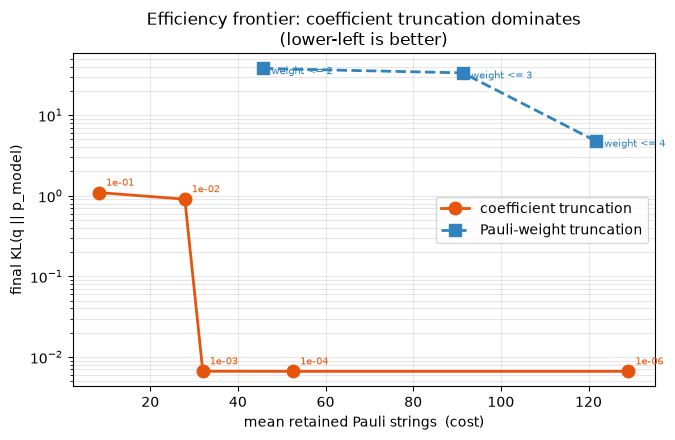

At comparable term budgets, coefficient truncation reaches orders-of-magnitude
lower KL than weight truncation on this densely-connected target -- matching the
paper's finding that coefficient truncation is the more effective knob in general.


In [12]:
# Pauli-weight truncation: cap the operator's weight instead of its coefficients
weight_runs = {w: train_truncated(1e-6, max_weight=w) for w in (2, 3, 4)}

fig, ax = plt.subplots(figsize=(6.9, 4.5))
cx = [runs[c][1].mean() for c in cutoffs]
cy = [runs[c][0][-1] for c in cutoffs]
ax.plot(cx, cy, "o-", c="#e6550d", lw=2, ms=9, label="coefficient truncation", zorder=3)
for c, x, y in zip(cutoffs, cx, cy):
    ax.annotate(f"{c:.0e}", (x, y), textcoords="offset points", xytext=(5, 5),
                fontsize=7.5, color="#e6550d")

wx = [weight_runs[w][1].mean() for w in (2, 3, 4)]
wy = [weight_runs[w][0][-1] for w in (2, 3, 4)]
ax.plot(wx, wy, "s--", c="#3182bd", lw=2, ms=9, label="Pauli-weight truncation", zorder=3)
for w, x, y in zip((2, 3, 4), wx, wy):
    ax.annotate(f"weight <= {w}", (x, y), textcoords="offset points", xytext=(6, -4),
                fontsize=7.5, color="#3182bd")

ax.set_yscale("log")
ax.set_xlabel("mean retained Pauli strings  (cost)")
ax.set_ylabel("final KL(q || p_model)")
ax.set_title("Efficiency frontier: coefficient truncation dominates\n(lower-left is better)")
ax.legend(); ax.grid(alpha=0.3, which="both")
plt.tight_layout(); plt.show()

print("At comparable term budgets, coefficient truncation reaches orders-of-magnitude")
print("lower KL than weight truncation on this densely-connected target -- matching the")
print("paper's finding that coefficient truncation is the more effective knob in general.")

For this all-to-all target, coefficient truncation is far more effective: it reaches low
KL with a few dozen terms, while weight truncation needs many more and still lags. The
reason is the one the paper gives — coefficient truncation adapts to the *actual*
magnitudes the evolution produces (and it already absorbs part of weight truncation,
since high-weight strings tend to accumulate small coefficients), whereas a hard weight
cap discards terms the state genuinely needs. Weight truncation earns its keep on
low-weight-dominated (e.g. 1-D, short-range) problems; coefficient truncation is the
sensible default.

## What it costs, and when to reach for it

The cost is the **number of retained Pauli strings**, and it is reported up front.

In [13]:
est = model.state().resource_estimate()
for k, v in est.items():
    print(f"   {k:22s} {v}")

   n_qubits               4
   n_parameters           14
   trotter_steps          32
   retained_pauli_terms   48
   coeff_cutoff           1e-08
   max_weight             None


**Use Pauli propagation when**

* the target is a finite-temperature / near-classical distribution — the operator stays
  sparse, and for a purely classical (all-$Z$) QBM the preparation is *exact*;
* the Hamiltonian is **densely connected** — all-to-all costs the same as a chain, where a
  tensor network would choke on the entanglement;
* you want **samples with exact likelihoods** — the locally normalised sampler gives both,
  which generative models rarely offer together.

**Be aware that**

* like every backend built for generative training (tensor network, VarQITE), it exposes
  expectations and sampling but **not** the QFI metrics, the energy-loss gradient, or
  $\log Z$ — those need `backend="dense"`;
* aggressive truncation makes $\rho$ non-physical; the sampler is designed for exactly
  this, and its error is controlled by the spectral negativity (Theorem III.1 of the
  sampling paper), available here as `state.spectral_negativity()` for small systems;
* the low-temperature / sharply-peaked regime drives the operator dense — that is the hard
  case, and the honest limit of the method;
* **this NumPy engine is a clear reference, not a speed record.** For the many-qubit,
  multi-threaded, GPU-accelerated runs in the papers, use
  [`PauliPropagation.jl`](https://github.com/Michele-Minervini/PauliSampling.jl).

## Recap

* A thermal state is a **sparse sum of Pauli strings**, reached by evolving the identity
  under imaginary time; each gate branches on **commutation**.
* It is **exact for commuting (classical) Hamiltonians** and first-order-Trotter for the
  rest; **truncation** trades retained terms for accuracy.
* It is **topology-agnostic** — dense connectivity is free.
* The **locally normalised sampler** turns the (possibly non-physical) truncated state
  into valid samples with exact likelihoods.
* A QBM trains end-to-end in the Pauli basis through the unchanged `qbm.learn` API, and
  matches exact training on generative tasks.